### Task 1: Load and validate the time series
Load the CSV into a DataFrame named fx. Parse Date as datetime and set it as the index. Confirm the index is sorted in ascending order and that all rate columns are numeric. Print the first five rows and the last five rows to verify the time span.

In [23]:
import pandas as pd

In [24]:
fx=pd.read_csv("C:\\Users\\Asus\\Downloads\\data_safe_copy.csv")

In [25]:
fx["Date"]=pd.to_datetime(fx["Date"])

In [26]:
fx.set_index(["Date"],inplace=True)

In [27]:
fx=fx.sort_index()

In [28]:
print("\nNumeric check:")
print(fx.apply(lambda x: pd.api.types.is_numeric_dtype(x)))


Numeric check:
EURUSD    True
GBPUSD    True
PLNUSD    True
USDPLN    True
USDJPY    True
AUDUSD    True
NZDUSD    True
USDCAD    True
USDCHF    True
EURPLN    True
GBPPLN    True
dtype: bool


In [29]:
print(fx.dtypes)

EURUSD    float64
GBPUSD    float64
PLNUSD    float64
USDPLN    float64
USDJPY    float64
AUDUSD    float64
NZDUSD    float64
USDCAD    float64
USDCHF    float64
EURPLN    float64
GBPPLN    float64
dtype: object


In [30]:
fx.head()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2025-01-02,1.02661,1.23826,0.240270,4.16199,157.4610,0.62033,0.55966,1.44067,0.91210,4.27274,5.15363
2025-01-03,1.03062,1.24267,0.241453,4.14160,157.3420,0.62176,0.56089,1.44467,0.90891,4.26841,5.14664
2025-01-06,1.03900,1.25188,0.244290,4.09350,157.6200,0.62427,0.56402,1.43330,0.90478,4.25315,5.12457
2025-01-07,1.03426,1.24771,0.242804,4.11855,158.0405,0.62326,0.56331,1.43683,0.90937,4.25965,5.13875
2025-01-08,1.03185,1.23638,0.241377,4.14290,158.3085,0.62132,0.56058,1.43758,0.91101,4.27485,5.12220


In [31]:
fx.tail()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2026-01-26,1.18777,1.36768,0.282362,3.54155,154.1550,0.69100,0.59697,1.37115,0.77720,4.20655,4.84370
2026-01-27,1.20426,1.38461,0.286789,3.48689,152.3020,0.70092,0.60433,1.35758,0.76114,4.19912,4.82798
2026-01-28,1.19562,1.38024,0.284316,3.51721,153.4235,0.70384,0.60594,1.35621,0.76859,4.20524,4.85459
2026-01-29,1.19695,1.38095,0.284600,3.51370,153.0050,0.70497,0.60751,1.34872,0.76476,4.20572,4.85224
2026-01-30,1.18534,1.36839,0.281465,3.55284,154.7785,0.69637,0.60212,1.36162,0.77302,4.21132,4.86167


### Task 2: Create two focused visualizations
Select two currency pairs, one that ends with USD and one that begins with USD. Create a line plot for each pair over time. Add clear titles and labels. Then create a third plot that shows both series together on the same axes so you can compare their movement directionally.

In [32]:
import matplotlib.pyplot as plt

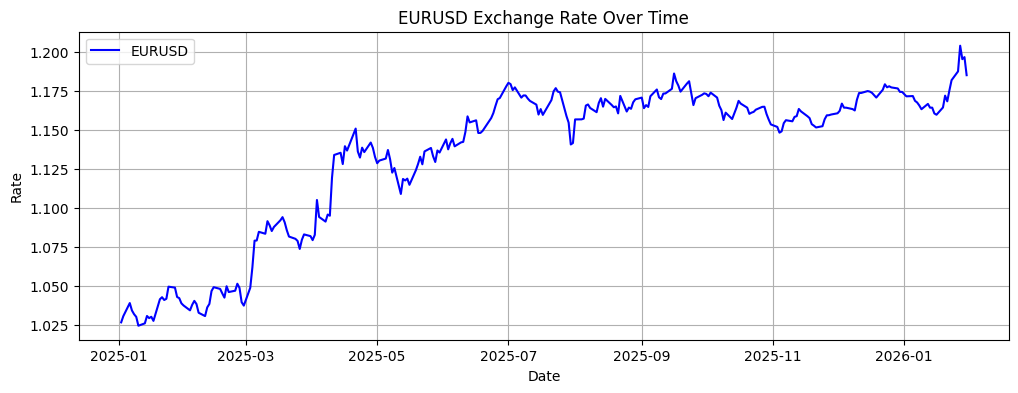

In [34]:
#EURUSD
plt.figure(figsize=(12,4))
plt.plot(fx.index, fx['EURUSD'] ,color='blue', label='EURUSD')
plt.title('EURUSD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.grid(True)
plt.legend()
plt.show()

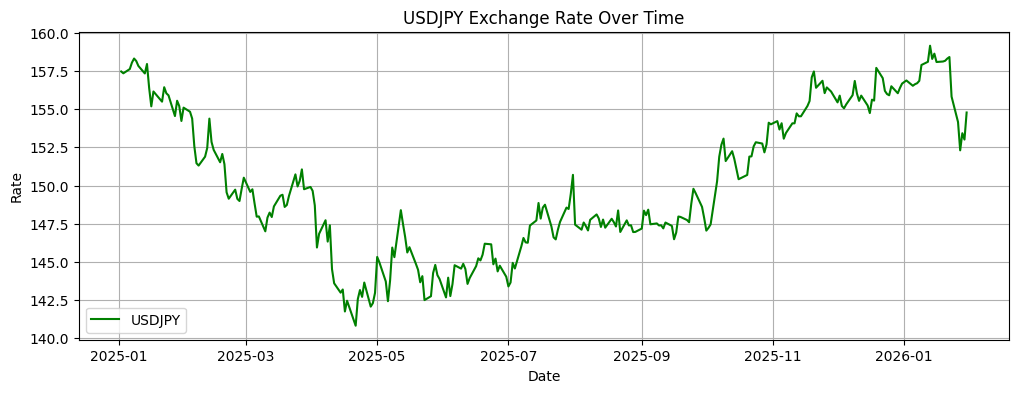

In [36]:
#USDJPY
plt.figure(figsize=(12,4))
plt.plot(fx.index, fx['USDJPY'],color='green', label='USDJPY')
plt.title('USDJPY Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.grid(True)
plt.legend()
plt.show()

In [44]:
ends_with=fx['EURUSD']
starts_with=fx['USDPLN']
combined = pd.concat([ends_with, start_with], axis=1)
combined

,EURUSD,USDPLN
Date,,
2025-01-02,1.02661,4.16199
2025-01-03,1.03062,4.14160
2025-01-06,1.03900,4.09350
2025-01-07,1.03426,4.11855
2025-01-08,1.03185,4.14290
...,...,...
2026-01-26,1.18777,3.54155
2026-01-27,1.20426,3.48689
2026-01-28,1.19562,3.51721


<Figure size 640x480 with 0 Axes>

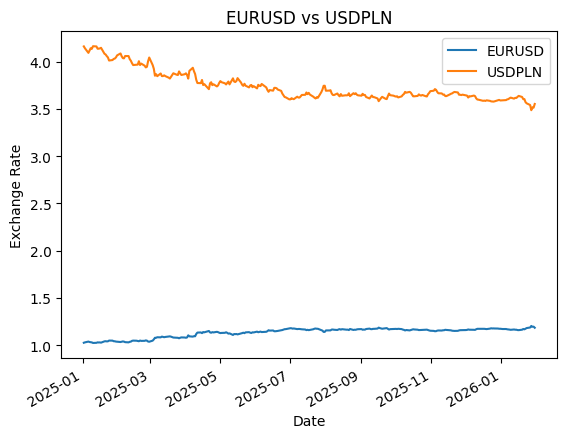

In [48]:
#combined
plt.figure()
combined.plot()
plt.title("EURUSD vs USDPLN")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

#### Task 3: Rolling features and validation
Compute a 7‑day rolling mean and a 7‑day rolling standard deviation for the two currency pairs you selected. Store the rolling series with clear names. Print the first ten rows of the rolling results and confirm that missing values appear only where the window is incomplete.

In [49]:
#mean
fx['EURUSD_7d_mean']=fx['EURUSD'].rolling(window=7).mean()
fx['USDJPY_7d_mean']=fx['USDJPY'].rolling(window=7).mean()

In [50]:
#std
fx['EURUSD_7d_std']=fx['EURUSD'].rolling(window=7).std()
fx['USDJPY_7d_std']=fx['USDJPY'].rolling(window=7).std()

In [51]:
rolling_cols = ['EURUSD_7d_mean', 'EURUSD_7d_std', 'USDJPY_7d_mean', 'USDJPY_7d_std']
print(fx[rolling_cols].head(10))

            EURUSD_7d_mean  EURUSD_7d_std  USDJPY_7d_mean  USDJPY_7d_std
Date                                                                    
2025-01-02             NaN            NaN             NaN            NaN
2025-01-03             NaN            NaN             NaN            NaN
2025-01-06             NaN            NaN             NaN            NaN
2025-01-07             NaN            NaN             NaN            NaN
2025-01-08             NaN            NaN             NaN            NaN
2025-01-09             NaN            NaN             NaN            NaN
2025-01-10        1.030991       0.004803      157.820571       0.363367
2025-01-13        1.030900       0.004905      157.802286       0.386934
2025-01-14        1.030911       0.004904      157.889214       0.330534
2025-01-15        1.029531       0.003367      157.712929       0.661458


In [56]:
print(fx[rolling_cols].isna().sum())

EURUSD_7d_mean    6
EURUSD_7d_std     6
USDJPY_7d_mean    6
USDJPY_7d_std     6
dtype: int64


#### Task 4: Simple baseline model
Build a one‑step‑ahead baseline forecast for one selected currency pair by shifting the series by one day. Create a new column baseline_pred and compute the absolute error between the actual value and the baseline prediction. Then compute the mean absolute error and print it.

Add a validation check that confirms the number of non‑missing predictions equals the number of rows minus one.

In [57]:
fx['EURUSD_baseline_pred'] = fx['EURUSD'].shift(1)

fx['EURUSD_baseline_error'] = (fx['EURUSD'] - fx['EURUSD_baseline_pred']).abs()

mae = fx['EURUSD_baseline_error'].mean()
print("Mean Absolute Error (EURUSD baseline):", mae)

Mean Absolute Error (EURUSD baseline): 0.004069426523297489


In [58]:
num_predictions = fx['EURUSD_baseline_pred'].notna().sum()
expected_predictions = len(fx) - 1  
print("Non-missing predictions:", num_predictions)
print("Expected predictions:", expected_predictions)
assert num_predictions == expected_predictions, "Prediction count does not match expected!"


Non-missing predictions: 279
Expected predictions: 279


In [59]:
print(fx[['EURUSD', 'EURUSD_baseline_pred', 'EURUSD_baseline_error']].head(10))

             EURUSD  EURUSD_baseline_pred  EURUSD_baseline_error
Date                                                            
2025-01-02  1.02661                   NaN                    NaN
2025-01-03  1.03062               1.02661                0.00401
2025-01-06  1.03900               1.03062                0.00838
2025-01-07  1.03426               1.03900                0.00474
2025-01-08  1.03185               1.03426                0.00241
2025-01-09  1.03015               1.03185                0.00170
2025-01-10  1.02445               1.03015                0.00570
2025-01-13  1.02597               1.02445                0.00152
2025-01-14  1.03070               1.02597                0.00473
2025-01-15  1.02934               1.03070                0.00136


#### Task 5: Short report with checks
Write a small report dictionary that includes the chosen currency pairs, the rolling window size, the mean absolute error from the baseline model, and the date range of the dataset. Print the report and include one explicit check, such as confirming that the rolling window size you used matches the value in the report.

In [60]:
fx.index = pd.to_datetime(fx.index, errors='coerce')

report = {
    'currency_pairs': ['EURUSD', 'USDJPY'],
    'rolling_window': 7,
    'baseline_mae': round(mae, 6),
    'date_range': [fx.index.min().strftime('%Y-%m-%d'), fx.index.max().strftime('%Y-%m-%d')]
}


In [61]:
print("FX Analysis Report:")
for key, value in report.items():
    print(f"{key}: {value}")

# Explicit check
assert report['rolling_window'] == 7, "Rolling window in report does not match actual value!"
print("\nCheck passed: Rolling window matches.")

FX Analysis Report:
currency_pairs: ['EURUSD', 'USDJPY']
rolling_window: 7
baseline_mae: 0.004069
date_range: ['2025-01-02', '2026-01-30']

Check passed: Rolling window matches.
